In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix
from fairlearn.metrics import MetricFrame, count, selection_rate
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
compas_two = pd.read_csv("compas-scores-two-years.csv")
compas_two.head(5)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
compas_two.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

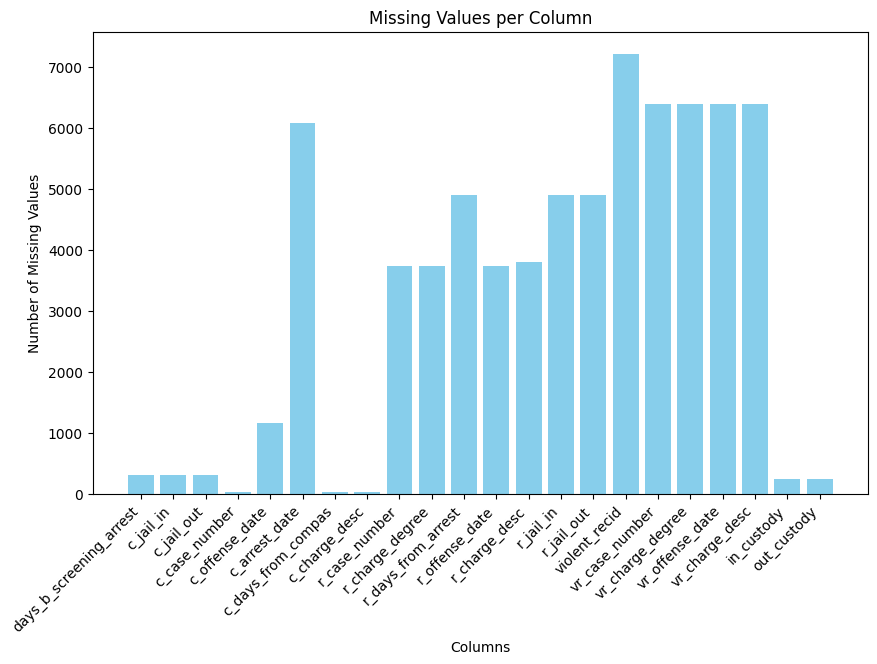

Columns with no missing values:
id
name
first
last
compas_screening_date
sex
dob
age
age_cat
race
juv_fel_count
decile_score
juv_misd_count
juv_other_count
priors_count
c_charge_degree
is_recid
is_violent_recid
type_of_assessment
decile_score.1
score_text
screening_date
v_type_of_assessment
v_decile_score
v_score_text
v_screening_date
priors_count.1
start
end
event
two_year_recid


In [4]:
missing_count = []
full_cols = []
missing_cols = []
for col in compas_two.columns:
    if compas_two[col].isna().sum() == 0:
        full_cols.append(col)
    else:
        missing_cols.append(col)
        missing_count.append(compas_two[col].isna().sum())

plt.figure(figsize=(10, 6))
plt.bar(missing_cols, missing_count, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Missing Values')
plt.xlabel("Columns")
plt.title('Missing Values per Column')
plt.show()
print("Columns with no missing values:")
for col in full_cols:
    print(col)

In [5]:
compas_two = compas_two.drop("violent_recid",axis=1)

In [6]:
numeric_cols = compas_two.select_dtypes(include=['float64', 'int64']).columns
for col in compas_two.columns:
    if col in numeric_cols:
        compas_two[col] = compas_two[col].fillna(compas_two[col].mean())
    else:
        compas_two[col] = compas_two[col].fillna(compas_two[col].mode()[0])
print("Missing values left:",compas_two.isna().sum().sum())

Missing values left: 0


In [7]:
compas_two['dob'] = pd.to_datetime(compas_two['dob'], dayfirst=True, errors='coerce')
compas_two['c_jail_in'] = pd.to_datetime(compas_two['c_jail_in'], dayfirst=True, errors='coerce')
compas_two['c_jail_out'] = pd.to_datetime(compas_two['c_jail_out'], dayfirst=True, errors='coerce')
compas_two['compas_screening_date'] = pd.to_datetime(compas_two['compas_screening_date'], dayfirst=True, errors='coerce')
compas_two['screening_date'] = pd.to_datetime(compas_two['screening_date'], dayfirst=True, errors='coerce')
compas_two['v_screening_date'] = pd.to_datetime(compas_two['v_screening_date'], dayfirst=True, errors='coerce')
compas_two['c_offense_date'] = pd.to_datetime(compas_two['c_offense_date'], dayfirst=True, errors='coerce')
compas_two['c_arrest_date'] = pd.to_datetime(compas_two['c_arrest_date'], dayfirst=True, errors='coerce')
compas_two['r_jail_in'] = pd.to_datetime(compas_two['r_jail_in'], dayfirst=True, errors='coerce')
compas_two['r_jail_out'] = pd.to_datetime(compas_two['r_jail_out'], dayfirst=True, errors='coerce')
compas_two['r_offense_date'] = pd.to_datetime(compas_two['r_offense_date'], dayfirst=True, errors='coerce')
compas_two['vr_offense_date'] = pd.to_datetime(compas_two['vr_offense_date'], dayfirst=True, errors='coerce')
compas_two['in_custody'] = pd.to_datetime(compas_two['in_custody'], dayfirst=True, errors='coerce')
compas_two['out_custody'] = pd.to_datetime(compas_two['out_custody'], dayfirst=True, errors='coerce')

In [8]:
X = compas_two.copy()
columns_to_drop = ['id', 'name', 'first', 'last', 'compas_screening_date','dob',
        'age_cat', 'decile_score','juv_misd_count', 'days_b_screening_arrest', 'c_jail_in', 
        'c_jail_out', 'c_case_number','c_offense_date', 'c_arrest_date', 
        'c_days_from_compas','c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'is_violent_recid',
       'vr_case_number', 'vr_charge_degree', 'vr_offense_date',
       'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text',
       'screening_date', 'v_type_of_assessment', 'v_decile_score',
       'v_score_text', 'v_screening_date', 'in_custody', 'out_custody',
       'priors_count.1', 'start', 'end', 'event', 'two_year_recid']
X = X.drop(columns=columns_to_drop)
charge_replace = {'F': 1, 'M': 0}
X['c_charge_degree'] = X['c_charge_degree'].replace(charge_replace)
X_og = X.copy()
X = pd.get_dummies(X, columns=['sex', 'race'], drop_first=True, dtype=float)
y = compas_two['two_year_recid']

In [9]:
X_og

,sex,age,race,juv_fel_count,juv_other_count,priors_count,c_charge_degree
0,Male,69,Other,0,0,0,1
1,Male,34,African-American,0,0,0,1
2,Male,24,African-American,0,1,4,1
3,Male,23,African-American,0,0,1,1
4,Male,43,Other,0,0,2,1
...,...,...,...,...,...,...,...
7209,Male,23,African-American,0,0,0,1
7210,Male,23,African-American,0,0,0,1
7211,Male,57,Other,0,0,0,1
7212,Female,33,African-American,0,0,3,0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

In [11]:
model_A = RandomForestClassifier(
    n_estimators=11,
    max_depth = 15,
    ccp_alpha=0.005,
    random_state=42,      
)
model_A.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=0.005, max_depth=15, n_estimators=11,
                       random_state=42)

--- ML Model Evaluation ---
ML Model ROC AUC: 0.7153
ML Model PR AUC: 0.6640
ML Model Brier Score: 0.2181


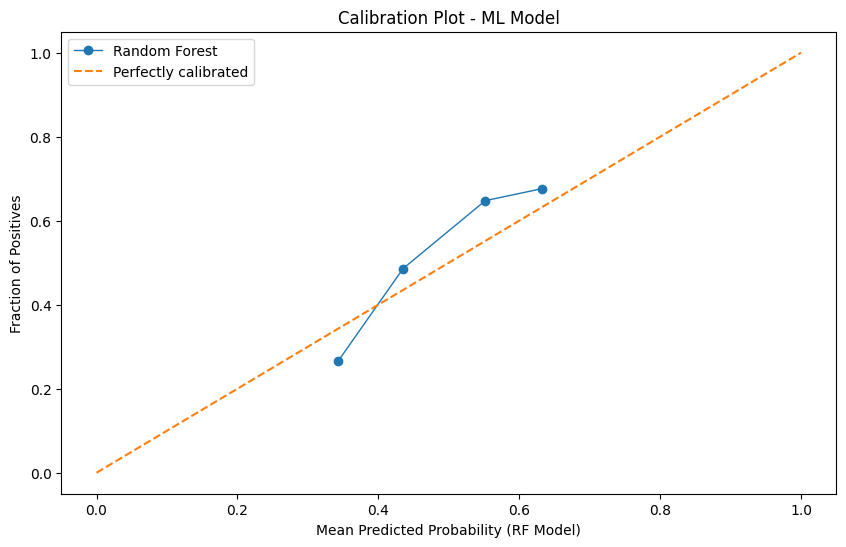

In [12]:
y_pred_A = model_A.predict_proba(X_test)[:, 1]
print("--- ML Model Evaluation ---")
auc_A = roc_auc_score(y_test, y_pred_A)
pr_auc_A = average_precision_score(y_test, y_pred_A)
brier_A = brier_score_loss(y_test, y_pred_A)
print(f"ML Model ROC AUC: {auc_A:.4f}")
print(f"ML Model PR AUC: {pr_auc_A:.4f}")
print(f"ML Model Brier Score: {brier_A:.4f}")

prob_true_A, prob_pred_A = calibration_curve(y_test, y_pred_A, n_bins=10, strategy='uniform') # or 'quantile'
plt.figure(figsize=(10, 6))
plt.plot(prob_pred_A, prob_true_A, marker='o', linewidth=1, label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel("Mean Predicted Probability (RF Model)")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Plot - ML Model")
plt.legend()
plt.show()

In [13]:
y_compas = (compas_two['decile_score']).astype(int)
X_compas_train, X_compas_test, y_compas_train, y_compas_test = train_test_split(X, y_compas, test_size=0.2, random_state=101, stratify=y_compas)


--- COMPAS Score Evaluation ---
COMPAS Score ROC AUC: 0.4929
COMPAS Score PR AUC (normalized): 0.4445
COMPAS Score Brier Score (normalized): 0.3326


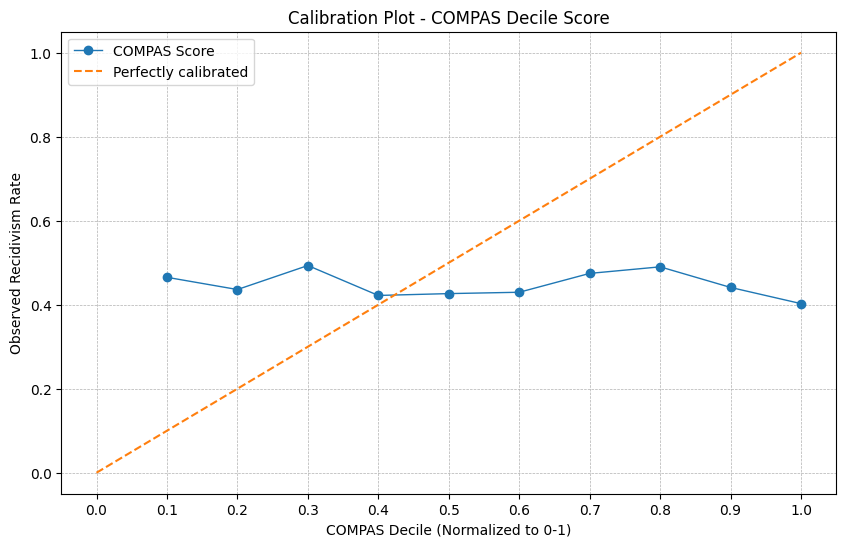

In [14]:
print("\n--- COMPAS Score Evaluation ---")
auc_compas = roc_auc_score(y_test, y_compas_test)
pr_auc_compas = average_precision_score(y_test, y_compas_test / 10.0) 
brier_compas = brier_score_loss(y_test, y_compas_test / 10.0)
print(f"COMPAS Score ROC AUC: {auc_compas:.4f}")
print(f"COMPAS Score PR AUC (normalized): {pr_auc_compas:.4f}")
print(f"COMPAS Score Brier Score (normalized): {brier_compas:.4f}")

compas_calibration_data = []
for decile in sorted(y_compas_test.unique()):
    mask = (y_compas_test == decile)
    if mask.sum() > 0:
        actual_rate = y_test[mask.values].mean()
        compas_calibration_data.append({'decile': decile, 'actual_rate': actual_rate, 'count': mask.sum()})

compas_cal_df = pd.DataFrame(compas_calibration_data)
plt.figure(figsize=(10, 6))
plt.plot(compas_cal_df['decile'] / 10.0, compas_cal_df['actual_rate'], marker='o', linewidth=1, label='COMPAS Score')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel("COMPAS Decile (Normalized to 0-1)")
plt.ylabel("Observed Recidivism Rate")
plt.title("Calibration Plot - COMPAS Decile Score")
plt.xticks(ticks=[i/10 for i in range(0, 11)]) 
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


Spearman correlation between ML probabilities and COMPAS scores: 0.0591


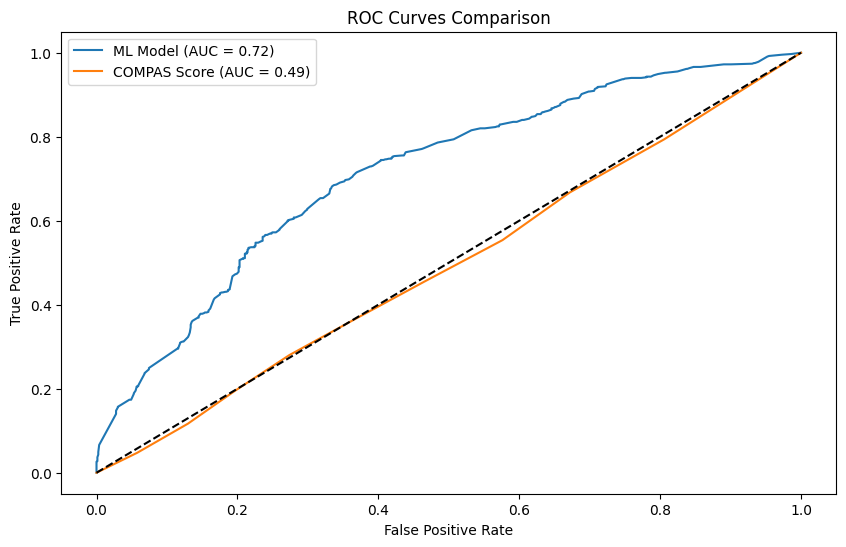

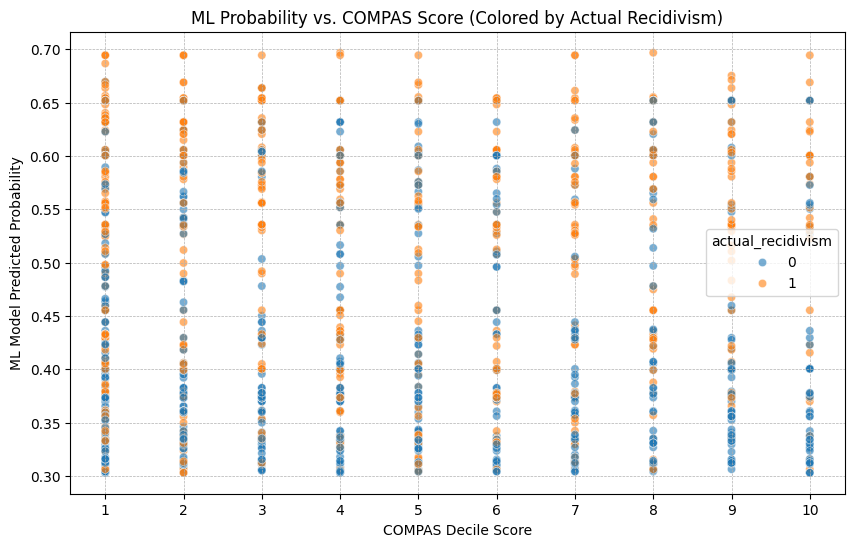


Analysis by COMPAS Decile:
   compas_decile  avg_ml_probability  actual_recidivism_rate  count
0              1            0.455072                0.465278    288
1              2            0.448891                0.436170    188
2              3            0.459671                0.493333    150
3              4            0.440239                0.422078    154
4              5            0.451800                0.426471    136
5              6            0.441889                0.429688    128
6              7            0.440650                0.474576    118
7              8            0.472200                0.490196    102
8              9            0.454526                0.441176    102
9             10            0.454708                0.402597     77


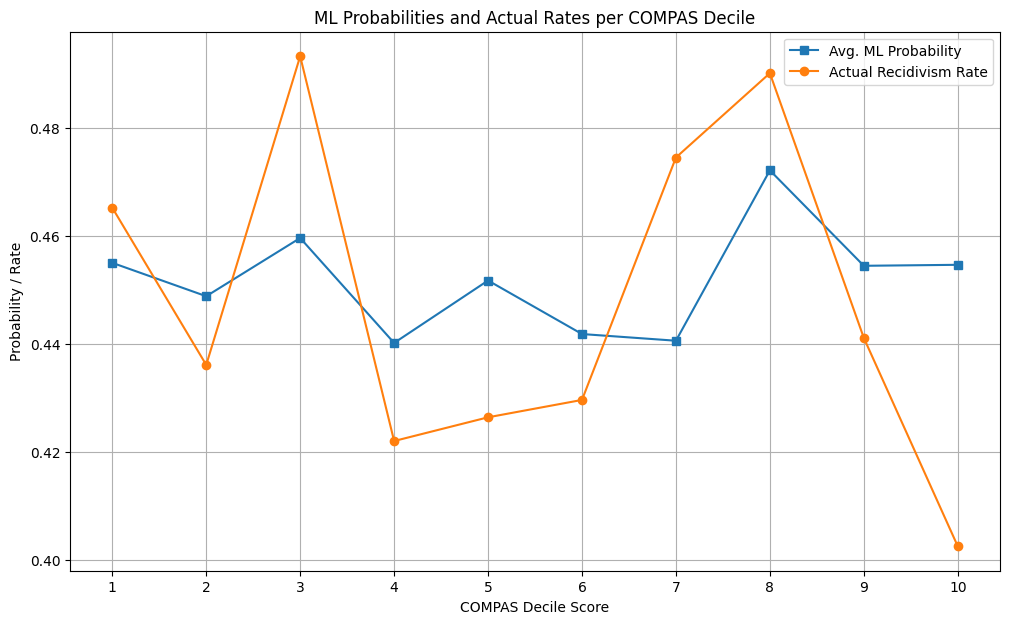

In [15]:
correlation = pd.Series(y_pred_A).corr(pd.Series(y_compas_test), method='spearman')
print(f"\nSpearman correlation between ML probabilities and COMPAS scores: {correlation:.4f}")
fpr_RF, tpr_RF, _ = roc_curve(y_test, y_pred_A)
fpr_compas, tpr_compas, _ = roc_curve(y_test, y_compas_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr_RF, tpr_RF, label=f'ML Model (AUC = {auc_A:.2f})')
plt.plot(fpr_compas, tpr_compas, label=f'COMPAS Score (AUC = {auc_compas:.2f})')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

compas_scores_np = np.array(y_compas_test)
ml_proba_np = np.array(y_pred_A)
actual_recid_np = np.array(y_test)

comparison_df = pd.DataFrame({
    'compas_score': compas_scores_np,
    'RF_probability': ml_proba_np,
    'actual_recidivism': actual_recid_np
})
plt.figure(figsize=(10, 6))
sns.scatterplot(data=comparison_df, x='compas_score', y='RF_probability', hue='actual_recidivism', alpha=0.6)
plt.xlabel("COMPAS Decile Score")
plt.ylabel("ML Model Predicted Probability")
plt.title("ML Probability vs. COMPAS Score (Colored by Actual Recidivism)")
plt.xticks(list(range(1, 11))) 
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

analysis_by_decile = []
for decile in sorted(comparison_df['compas_score'].unique()):
    subset = comparison_df[comparison_df['compas_score'] == decile]
    if not subset.empty:
        avg_ml_prob = subset['RF_probability'].mean()
        actual_rate = subset['actual_recidivism'].mean()
        decile_count = len(subset)
        analysis_by_decile.append({
            'compas_decile': decile,
            'avg_ml_probability': avg_ml_prob,
            'actual_recidivism_rate': actual_rate,
            'count': decile_count
        })
analysis_df = pd.DataFrame(analysis_by_decile)
print("\nAnalysis by COMPAS Decile:")
print(analysis_df)

# Plot for analysis_df
plt.figure(figsize=(12, 7))
plt.plot(analysis_df['compas_decile'], analysis_df['avg_ml_probability'], marker='s', linestyle='-', label='Avg. ML Probability')
plt.plot(analysis_df['compas_decile'], analysis_df['actual_recidivism_rate'], marker='o', linestyle='-', label='Actual Recidivism Rate')
plt.xlabel("COMPAS Decile Score")
plt.ylabel("Probability / Rate")
plt.title("ML Probabilities and Actual Rates per COMPAS Decile")
plt.xticks(analysis_df['compas_decile'])
plt.legend()
plt.grid(True)
plt.show()

In [16]:
X_og_train, X_og_test, y_og_train, y_og_test = train_test_split(X_og, y, test_size=0.2, random_state=101, stratify=y)
X_og_test

,sex,age,race,juv_fel_count,juv_other_count,priors_count,c_charge_degree
3836,Male,26,African-American,0,0,0,0
2521,Male,28,African-American,1,0,5,1
2525,Male,22,African-American,1,0,2,1
3176,Female,24,African-American,0,0,0,0
6780,Female,34,Caucasian,0,1,0,1
...,...,...,...,...,...,...,...
1474,Female,50,African-American,0,0,1,1
3897,Male,24,Hispanic,0,0,0,0
6314,Male,32,Hispanic,0,0,7,1
6800,Female,26,Caucasian,0,0,0,1


In [17]:
sensitive_features_race = X_og_test['race'].copy()
sensitive_features_sex = X_og_test['sex'].copy()

ML_THRESHOLD = 0.5 
COMPAS_THRESHOLD = 6 #deciles 6-10 are "high risk"

y_pred_binary_ml = (np.array(y_pred_A) >= ML_THRESHOLD).astype(int) 
compas_pred_binary = (np.array(y_compas_test) >= COMPAS_THRESHOLD).astype(int) 

def false_positive_rate_metric(y_true, y_pred):
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0,1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0] if y_true_arr.max()==0 and y_pred_arr.max()==0 else 0, 
                                                      0, # FP
                                                      0, # FN
                                                      cm[0,0] if y_true_arr.max()==1 and y_pred_arr.max()==1 else 0) 
    if (fp + tn) == 0:
        return 0
    return fp / (fp + tn)

def false_negative_rate_metric(y_true, y_pred):
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    cm = confusion_matrix(y_true_arr, y_pred_arr, labels=[0,1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0] if y_true_arr.max()==0 and y_pred_arr.max()==0 else 0,
                                                      0,
                                                      0,
                                                      cm[0,0] if y_true_arr.max()==1 and y_pred_arr.max()==1 else 0)
    if (fn + tp) == 0:
        return 0
    return fn / (fn + tp)
binary_metrics = {
    'accuracy': accuracy_score,
    'precision': lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
    'recall_tpr': lambda y_true, y_pred: recall_score(y_true, y_pred, zero_division=0), 
    'fpr': false_positive_rate_metric, 
    'fnr': false_negative_rate_metric, 
    'selection_rate': selection_rate,  
    'count': count
}
proba_metrics = {
    'roc_auc': roc_auc_score,
    'count': count
}
print("\n--- Fairness Audit: Your ML Model (y_pred_A) ---")

# By Race (Binary Predictions)
mf_ml_race_binary = MetricFrame(metrics=binary_metrics,
                                y_true=y_test,
                                y_pred=y_pred_binary_ml,
                                sensitive_features=sensitive_features_race)
print("\nML Model Metrics by Race (Binary Predictions):")
print(mf_ml_race_binary.by_group)
print("\nDifference from overall (ML, Race, Binary):")
print(mf_ml_race_binary.difference(method='between_groups')) 
print("\nRatio to overall (ML, Race, Binary):")
print(mf_ml_race_binary.ratio(method='between_groups')) 


# By Race (Probability Predictions for ROC AUC)
mf_ml_race_proba = MetricFrame(metrics=proba_metrics,
                               y_true=y_test,
                               y_pred=y_pred_A, 
                               sensitive_features=sensitive_features_race)
print("\nML Model ROC AUC by Race:")
print(mf_ml_race_proba.by_group)
print("\nDifference from overall (ML, Race, ROC AUC):")
print(mf_ml_race_proba.difference(method='between_groups'))
print("\nRatio to overall (ML, Race, ROC AUC):")
print(mf_ml_race_proba.ratio(method='between_groups'))


# By Sex (Binary Predictions)
mf_ml_sex_binary = MetricFrame(metrics=binary_metrics,
                               y_true=y_test,
                               y_pred=y_pred_binary_ml,
                               sensitive_features=sensitive_features_sex)
print("\nML Model Metrics by Sex (Binary Predictions):")
print(mf_ml_sex_binary.by_group)
print("\nDifference from overall (ML, Sex, Binary):")
print(mf_ml_sex_binary.difference(method='between_groups'))
print("\nRatio to overall (ML, Sex, Binary):")
print(mf_ml_sex_binary.ratio(method='between_groups'))

# By Sex (Probability Predictions for ROC AUC)
mf_ml_sex_proba = MetricFrame(metrics=proba_metrics,
                              y_true=y_test,
                              y_pred=y_pred_A, 
                              sensitive_features=sensitive_features_sex)
print("\nML Model ROC AUC by Sex:")
print(mf_ml_sex_proba.by_group)
print("\nDifference from overall (ML, Sex, ROC AUC):")
print(mf_ml_sex_proba.difference(method='between_groups'))
print("\nRatio to overall (ML, Sex, ROC AUC):")
print(mf_ml_sex_proba.ratio(method='between_groups'))


# --- Audit for COMPAS SCORE (using y_compas_test) ---
print("\n\n--- Fairness Audit: COMPAS Score (y_compas_test) ---")

# By Race (Binary Predictions from COMPAS)
mf_compas_race_binary = MetricFrame(metrics=binary_metrics,
                                    y_true=y_test,
                                    y_pred=compas_pred_binary,
                                    sensitive_features=sensitive_features_race)
print("\nCOMPAS Metrics by Race (Binary Predictions):")
print(mf_compas_race_binary.by_group)
print("\nDifference from overall (COMPAS, Race, Binary):")
print(mf_compas_race_binary.difference(method='between_groups'))
print("\nRatio to overall (COMPAS, Race, Binary):")
print(mf_compas_race_binary.ratio(method='between_groups'))

# By Race (COMPAS Scores for ROC AUC - treat decile scores as risk scores)
mf_compas_race_proba = MetricFrame(metrics=proba_metrics,
                                   y_true=y_test,
                                   y_pred=y_compas_test, 
                                   sensitive_features=sensitive_features_race)
print("\nCOMPAS ROC AUC by Race:")
print(mf_compas_race_proba.by_group)
print("\nDifference from overall (COMPAS, Race, ROC AUC):")
print(mf_compas_race_proba.difference(method='between_groups'))
print("\nRatio to overall (COMPAS, Race, ROC AUC):")
print(mf_compas_race_proba.ratio(method='between_groups'))


# By Sex (Binary Predictions from COMPAS)
mf_compas_sex_binary = MetricFrame(metrics=binary_metrics,
                                   y_true=y_test,
                                   y_pred=compas_pred_binary,
                                   sensitive_features=sensitive_features_sex)
print("\nCOMPAS Metrics by Sex (Binary Predictions):")
print(mf_compas_sex_binary.by_group)
print("\nDifference from overall (COMPAS, Sex, Binary):")
print(mf_compas_sex_binary.difference(method='between_groups'))
print("\nRatio to overall (COMPAS, Sex, Binary):")
print(mf_compas_sex_binary.ratio(method='between_groups'))

# By Sex (COMPAS Scores for ROC AUC)
mf_compas_sex_proba = MetricFrame(metrics=proba_metrics,
                                  y_true=y_test,
                                  y_pred=y_compas_test,
                                  sensitive_features=sensitive_features_sex)
print("\nCOMPAS ROC AUC by Sex:")
print(mf_compas_sex_proba.by_group)
print("\nDifference from overall (COMPAS, Sex, ROC AUC):")
print(mf_compas_sex_proba.difference(method='between_groups'))
print("\nRatio to overall (COMPAS, Sex, ROC AUC):")
print(mf_compas_sex_proba.ratio(method='between_groups'))

# Intersectionality (Race and Sex combined) ---
if 'race' in X_og.columns and 'sex' in X_og.columns:
    sensitive_features_race_sex = (X_og_test['race'].astype(str) + "_" + X_og_test['sex'].astype(str)).rename('race_sex')
    print("\n--- Intersectionality Audit: Your ML Model (Race & Sex) ---")
    mf_ml_intersection_binary = MetricFrame(metrics=binary_metrics,
                                            y_true=y_test,
                                            y_pred=y_pred_binary_ml,
                                            sensitive_features=sensitive_features_race_sex)
    print("\nML Model Metrics by Race_Sex (Binary Predictions):")
    print(mf_ml_intersection_binary.by_group)

    print("\n--- Intersectionality Audit: COMPAS Score (Race & Sex) ---")
    mf_compas_intersection_binary = MetricFrame(metrics=binary_metrics,
                                                y_true=y_test,
                                                y_pred=compas_pred_binary,
                                                sensitive_features=sensitive_features_race_sex)
    print("\nCOMPAS Metrics by Race_Sex (Binary Predictions):")
    print(mf_compas_intersection_binary.by_group)


--- Fairness Audit: Your ML Model (y_pred_A) ---

ML Model Metrics by Race (Binary Predictions):
                  accuracy  precision  recall_tpr       fpr       fnr  \
race                                                                    
African-American  0.633333   0.681818    0.585938  0.312500  0.414062   
Asian             1.000000   1.000000    1.000000  0.000000  0.000000   
Caucasian         0.705411   0.644928    0.475936  0.157051  0.524064   
Hispanic          0.686567   0.606061    0.408163  0.152941  0.591837   
Native American   0.800000   0.500000    1.000000  0.250000  0.000000   
Other             0.708861   0.592593    0.571429  0.215686  0.428571   

                  selection_rate  count  
race                                     
African-American        0.458333  720.0  
Asian                   0.166667    6.0  
Caucasian               0.276553  499.0  
Hispanic                0.246269  134.0  
Native American         0.400000    5.0  
Other                  